Assignment 1 b

Task 1: Stochastic Gradient Descent
In class we covered the baseline stochastic gradient descent and solved a regularized linear regression problem. For the same dataset we covered develop from scratch the baseline SGD algorithm using only torch.xyz namespaced libraries and show explicitly the equations related to calculating the gradients and updating the weights. You can type the equations in your notebook in latex format.

Clearly state the hyperparameters you used and present the loss vs epoch plot that demonstrates the convergence of the algorithm by plotting the final hypothesis.

In [22]:
import seaborn as sns  # Import Seaborn for enhanced data visualization
import numpy as np  # Import NumPy for numerical operations
from scipy.stats import multivariate_normal  # Import multivariate_normal for generating multivariate distributions
import matplotlib.pyplot as plt  # Import Matplotlib for plotting

# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Set the theme for Seaborn plots
sns.set_theme()

# Here we are setting a random seed for reproducibility
np.random.seed(1234567)


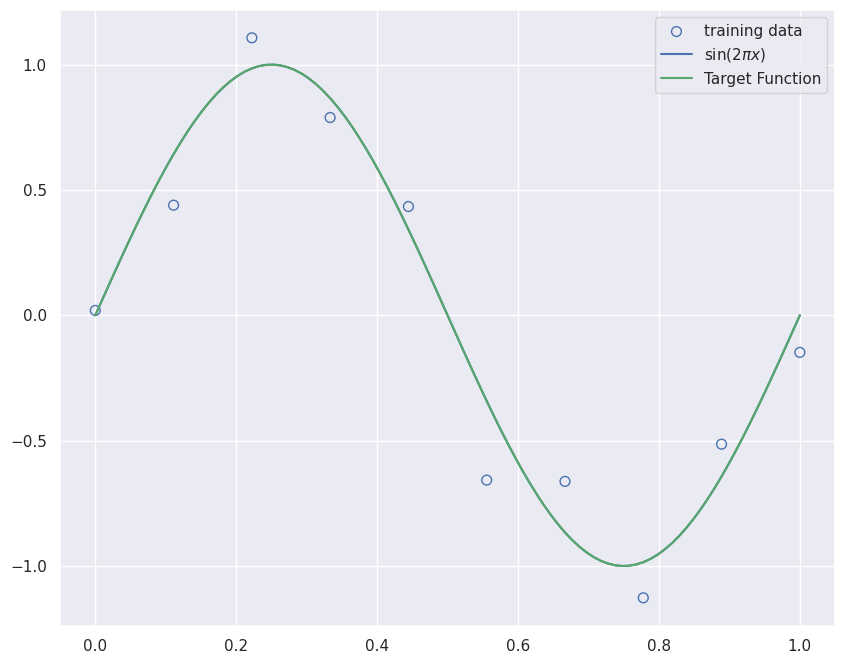

In [23]:
import torch  # Import PyTorch for tensor operations

# Define a class for generating polynomial features which we require further
class PolynomialFeature:
    def __init__(self, degree):
        # Initialize the class with a specific polynomial degree
        self.degree = degree

    def transform(self, x):
        # Generate polynomial features up to the specified degree
        return torch.cat([x ** i for i in range(self.degree + 1)], dim=-1)  # Concatenate powers of x

# Function to create toy data based on a given function
def create_toy_data(func, sample_size, std, domain=[0, 1]):
    # Generate equally spaced values within the specified domain
    x = np.linspace(domain[0], domain[1], sample_size)
    np.random.shuffle(x)  # Shuffle the x values randomly
    # Compute y values by applying the function and adding Gaussian noise
    y = func(x) + np.random.normal(scale=std, size=x.shape)
    return x, y  # Return the generated x and y data

# Define a sinusoidal function to be used as the underlying function for data generation
def sinusoidal(x):
    return np.sin(2 * np.pi * x)  # Calculate the sine of 2πx

# Create training and test data
x_train, y_train = create_toy_data(sinusoidal, 10, 0.25)  # Generate 10 samples of training data
x_test = np.linspace(0, 1, 100)  # Generate 100 test samples equally spaced in the domain
y_test = sinusoidal(x_test)  # Compute the corresponding y values for the test data

# Convert data to PyTorch tensors for model training
# Convert y_test to a tensor and add a dimension
x_train_torch = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)
y_train_torch = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
x_test_torch = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1)
y_test_torch = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Plot training data
plt.figure(figsize=[10, 8])
plt.scatter(x_train, y_train, facecolor="none", edgecolor="b", s=50, label="training data")
plt.plot(x_test, y_test, label="$\sin(2\pi x)$")
plt.plot(x_test, y_test, "-g", label="Target Function")
plt.legend()
plt.show()


### Linear Regression Equations

#### 1. **Prediction**

The predicted values $\hat{y}$ are computed as:

$$
\hat{y} = X_{\text{train}} \cdot w + b
$$

#### 2. **Mean Squared Error (MSE) Loss**

The mean squared error (MSE) loss is calculated as:

$$
\text{MSE Loss} = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{y}_i - y_i \right)^2
$$

#### 3. **L2 Regularization (Weight Decay)**

L2 regularization is added to the loss to prevent overfitting:

$$
\text{L2 Regularization} = \lambda \sum_{j=1}^{M} w_j^2
$$


#### 4. **Total Loss (MSE + L2 Regularization)**

The total loss \( L \) is:

$$
L = \text{MSE Loss} + \text{L2 Regularization}
$$

or explicitly:

$$
L = \frac{1}{N} \sum_{i=1}^{N} \left( \hat{y}_i - y_i \right)^2 + \lambda \sum_{j=1}^{M} w_j^2
$$

#### 5. **Weight and Bias Updates**

The weights and bias are updated using gradient descent:

$$
w = w - \alpha \frac{\partial L}{\partial w}
$$

$$
b = b - \alpha \frac{\partial L}{\partial b}
$$




-------------------Checking for M = 
1
Final Epoch 999, Final Loss: 0.28045228123664856


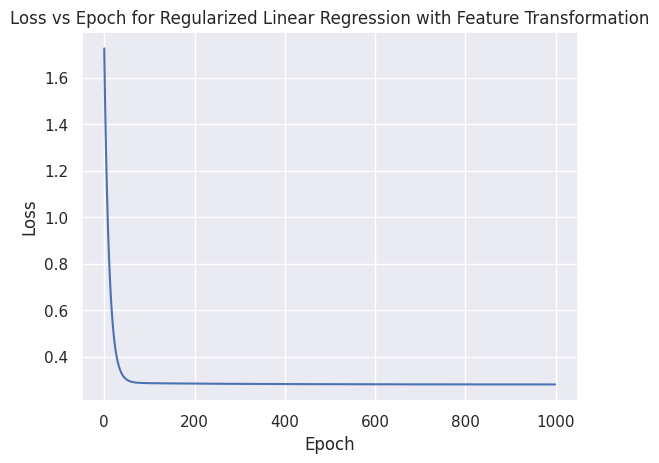


-------------------Checking for M = 
2
Final Epoch 999, Final Loss: 0.2798422574996948


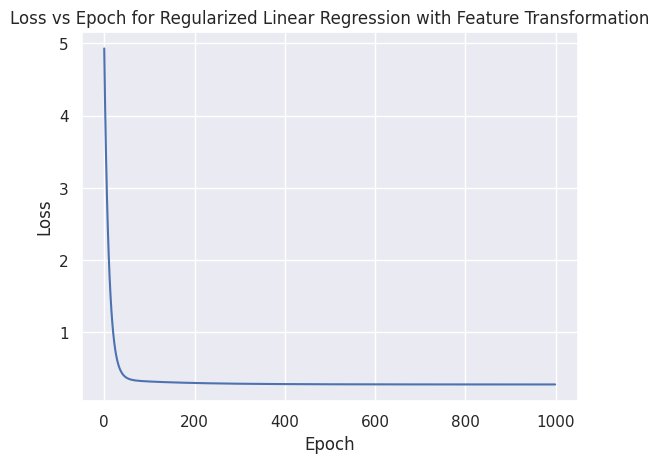


-------------------Checking for M = 
3
Final Epoch 999, Final Loss: 0.29970234632492065


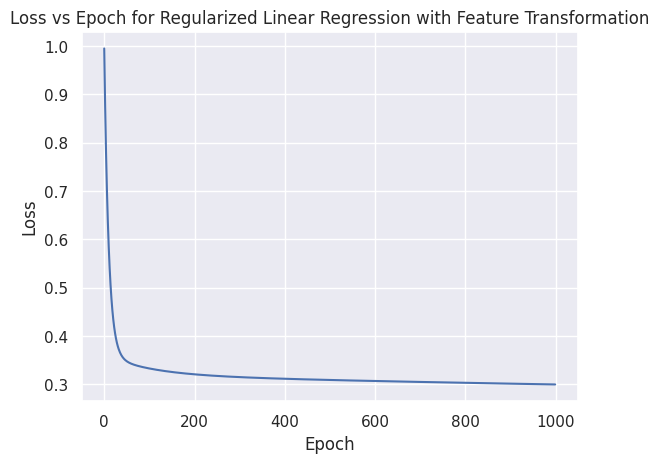


-------------------Checking for M = 
4
Final Epoch 999, Final Loss: 0.25533556938171387


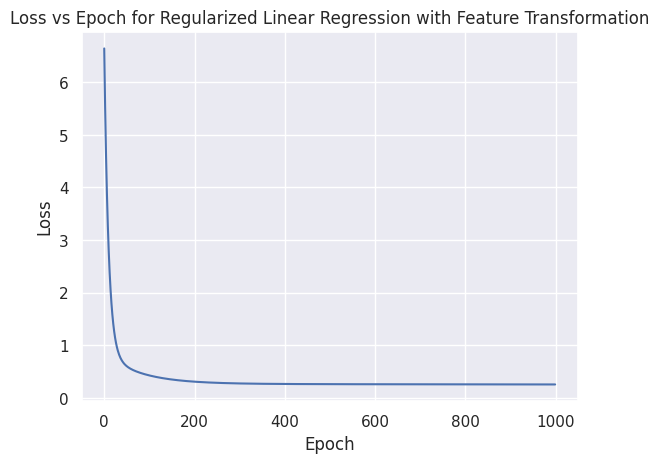


-------------------Checking for M = 
5
Final Epoch 999, Final Loss: 0.30834415555000305


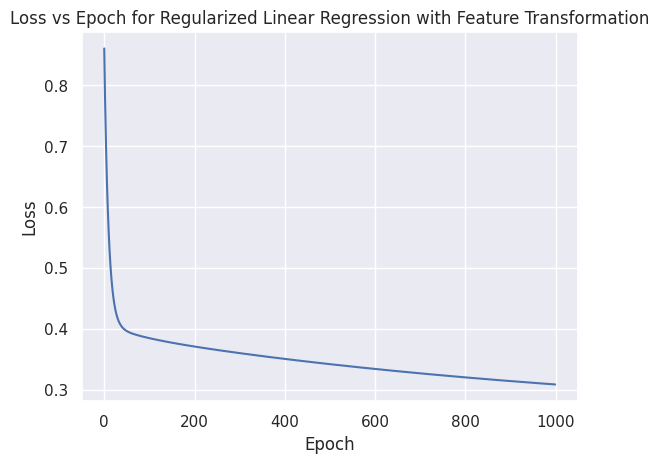


-------------------Checking for M = 
6
Final Epoch 999, Final Loss: 0.3807857036590576


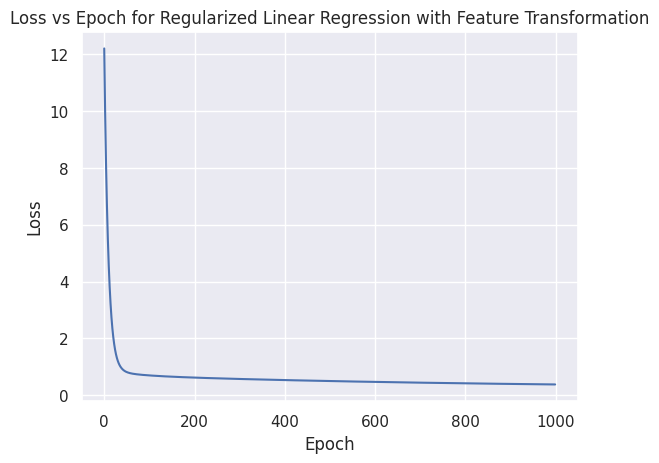


-------------------Checking for M = 
7
Final Epoch 999, Final Loss: 0.22994372248649597


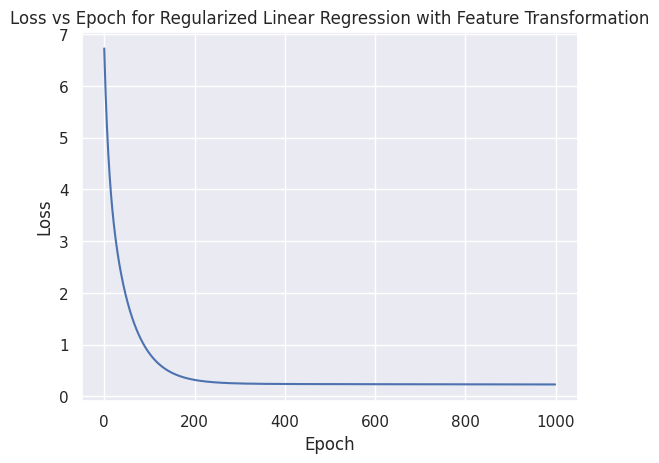


-------------------Checking for M = 
8
Final Epoch 999, Final Loss: 0.17848822474479675


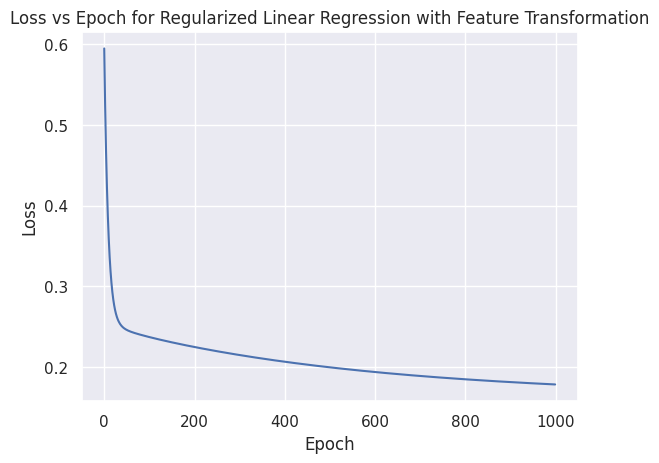


-------------------Checking for M = 
9
Final Epoch 999, Final Loss: 0.18527363240718842


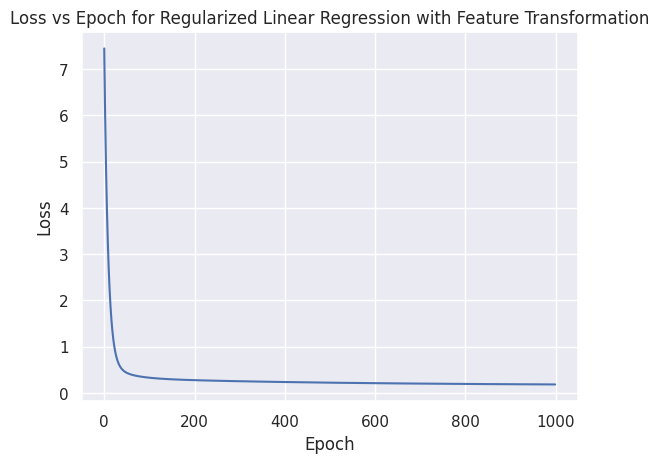


-------------------Checking for M = 
10
Final Epoch 999, Final Loss: 0.2633720636367798


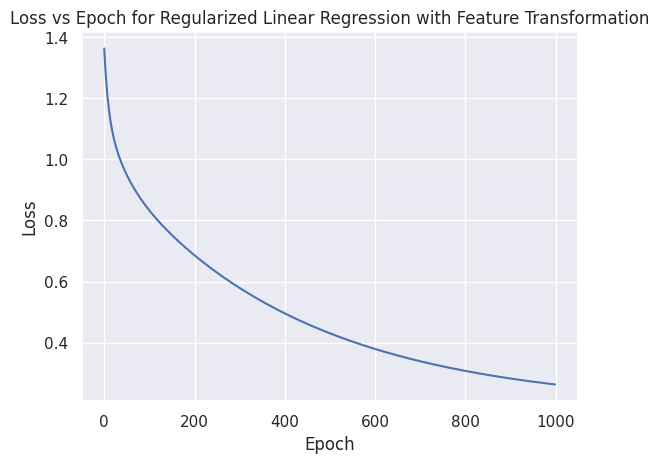


-------------------Checking for M = 
11
Final Epoch 999, Final Loss: 0.19538123905658722


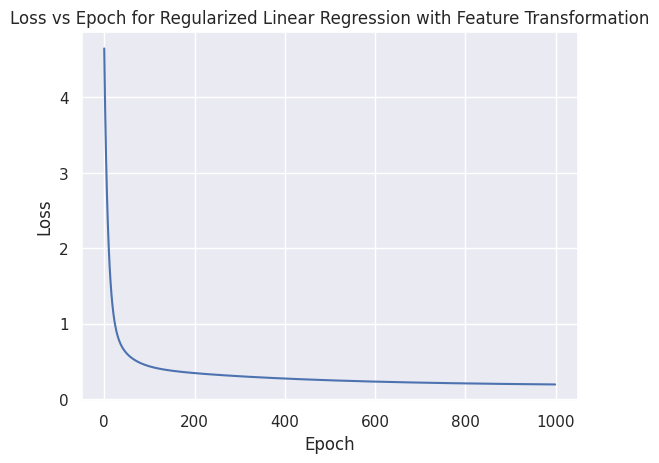

In [24]:
import torch
import matplotlib.pyplot as plt

class PolynomialFeature:
    def __init__(self, degree):
        self.degree = degree

    def transform(self, x):
        return torch.cat([x ** i for i in range(self.degree + 1)], dim=-1)

def train_polynomial_regression(x_train, y_train, x_test, M, learning_rate=0.01, num_epochs=1000, reg_lambda=0.001):
    print("\n-------------------Checking for M = ")
    print(M)
    # Initialize polynomial features
    feature = PolynomialFeature(M)

    # Transform the data
    X_train = feature.transform(x_train)
    X_test = feature.transform(x_test)

    # Initialize weights and bias
    weights = torch.randn(X_train.shape[1], 1, requires_grad=True)
    bias = torch.randn(1, requires_grad=True)

    # Store losses for plotting
    losses = []

    # Training loop
    for epoch in range(num_epochs):

        # EQUATION 1 :PREDICTION:

        y_pred = X_train @ weights + bias

        # EQUATION 2 :Mean Sqaured Loss
        mse_loss = ((y_pred - y_train) ** 2).mean()

        # EQUATION 3 L2 regularization
        l2_reg = reg_lambda * (weights ** 2).sum()
        loss = mse_loss + l2_reg

        # Backward pass
        loss.backward()


        # Update weights and bias using SGD principles
        with torch.no_grad():
            # EQUATION 4 update weight
            weights -= learning_rate * weights.grad
            # EQUATION 5 update bias
            bias -= learning_rate * bias.grad

        #Prep work for the next iteration
        weights.grad.zero_()
        bias.grad.zero_()
        losses.append(loss.item())


    print(f"Final Epoch {epoch}, Final Loss: {loss.item()}")
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epoch for Regularized Linear Regression with Feature Transformation")
    plt.show()





# Checking what M fits best
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=1)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=2)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=3)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=4)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=5)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=6)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=7)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=8)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=9)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=10)
train_polynomial_regression(x_train_torch, y_train_torch, x_test_torch, M=11)


Task 2: Momentum
In this exercise you start from the implementation of Task 1 (the regularized linear regression problem) and study the convergence speed by implement from scratch an alternative: the momentum algorithm.

Clearly state the hyperparameters you used and present the loss vs epoch plot that demonstrates the convergence of each algorithm and plotting the final hypothesis - you can include all compatible plots in the same figure.

Final Epoch Momentum 999, Final Loss for Momentum: 0.15022169053554535


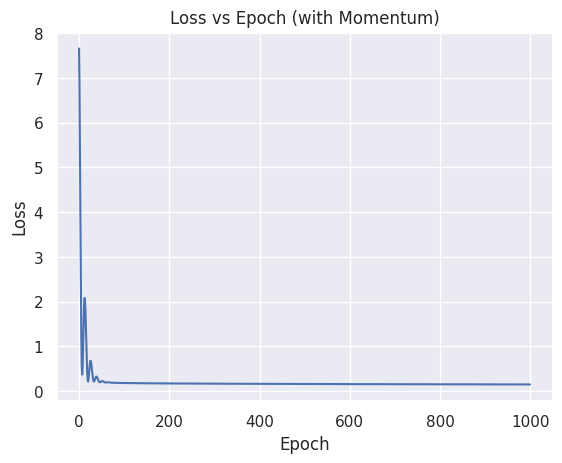

Mean Squared Error (MSE) on the test set: 0.2442
Mean Absolute Error (MAE) on the test set: 0.4403
R-squared (R²) Score on the test set: 0.5067


In [29]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set the polynomial degree M, which has shown the least loss in previous experiments
M = 9

# Initialize the PolynomialFeature class with the chosen degree M
feature = PolynomialFeature(M)

# Transform the training and test data into polynomial features
X_train = feature.transform(x_train_torch)
X_test = feature.transform(x_test_torch)

# Initialize weights and bias for the transformed feature dimensionality
weights = torch.randn(X_train.shape[1], 1, requires_grad=True)  # Random initialization for weights
bias = torch.randn(1, requires_grad=True)  # Random initialization for bias

# Initialize velocity terms for weights and bias (for momentum)
v_weights = torch.zeros_like(weights)  # Velocity for weights
v_bias = torch.zeros_like(bias)        # Velocity for bias

# Hyperparameters for training
learning_rate = 0.01  # Step size for weight updates
momentum = 0.9        # Momentum factor to accelerate convergence
num_epochs = 1000     # Number of training iterations
reg_lambda = 0.001    # L2 regularization strength to prevent overfitting

# List to store loss values for plotting
losses = []

# Training loop for the specified number of epochs
for epoch in range(num_epochs):
    # Forward pass: calculate predictions using the current weights and bias
    y_pred = X_train @ weights + bias

    # Compute the Mean Squared Error (MSE) loss
    mse_loss = ((y_pred - y_train_torch) ** 2).mean()

    # Add the L2 regularization term to the loss (Ridge regression)
    l2_reg = reg_lambda * (weights ** 2).sum()
    loss = mse_loss + l2_reg

    # Backward pass: compute gradients of the loss with respect to weights and bias
    loss.backward()

    # Update weights and bias using momentum
    with torch.no_grad():
        # Update velocities for weights and bias
        v_weights = momentum * v_weights + learning_rate * weights.grad
        v_bias = momentum * v_bias + learning_rate * bias.grad

        # Update weights and bias using their respective velocities
        weights -= v_weights
        bias -= v_bias

    # Zero out gradients for the next iteration
    weights.grad.zero_()
    bias.grad.zero_()

    # Store the current loss value for later plotting
    losses.append(loss.item())

    # Print the current loss every 50 epochs for monitoring

print(f"Final Epoch Momentum {epoch}, Final Loss for Momentum: {loss.item()}")
# Plot the loss curve over epochs
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (with Momentum)")
plt.show()

# Convert predictions and true values to NumPy arrays for evaluation
y_test_pred_np = y_test_pred.detach().cpu().numpy().squeeze()  # Predictions for the test set
y_test_np = y_test_torch.detach().cpu().numpy().squeeze()      # True values for the test set

# Calculate Mean Squared Error (MSE) for the test set
mse = np.mean((y_test_pred_np - y_test_np) ** 2)
print(f"Mean Squared Error (MSE) on the test set: {mse:.4f}")

# Calculate Mean Absolute Error (MAE) for the test set
mae = np.mean(np.abs(y_test_pred_np - y_test_np))
print(f"Mean Absolute Error (MAE) on the test set: {mae:.4f}")

# Calculate R-squared (R²) score to evaluate model performance
ss_total = np.sum((y_test_np - np.mean(y_test_np)) ** 2)         # Total sum of squares
ss_residual = np.sum((y_test_np - y_test_pred_np) ** 2)        # Residual sum of squares
r2_score = 1 - (ss_residual / ss_total)  # R² score calculation
print(f"R-squared (R²) Score on the test set: {r2_score:.4f}")


Here we will be plotting both.
Using Momentum and without using momentum.
Let us see how fast Momentum converges

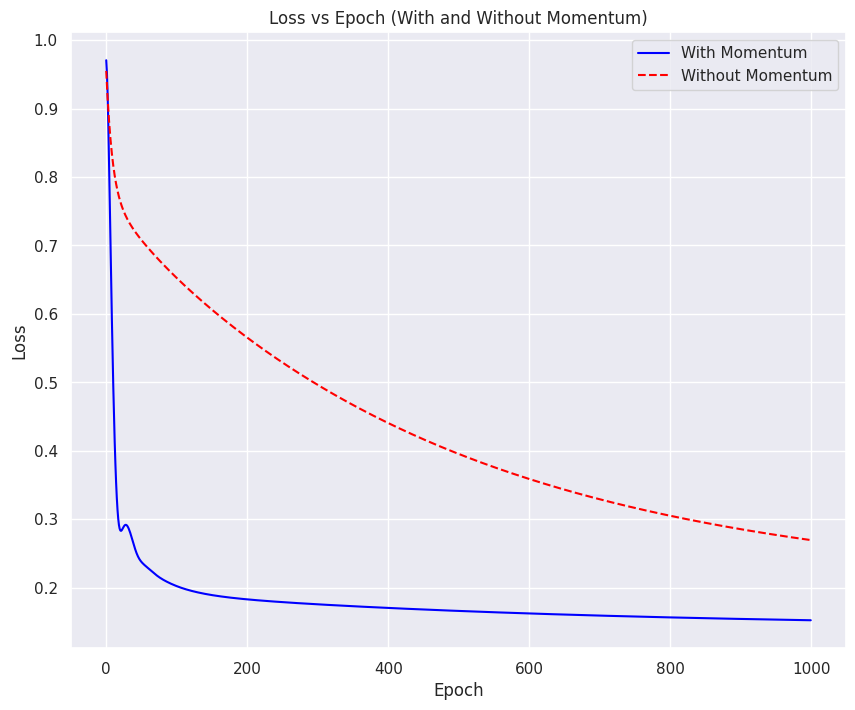

In [30]:
import torch
import matplotlib.pyplot as plt

def train_model(momentum=False):
    # Initialize weights and bias for the model
    weights = torch.randn(X_train.shape[1], 1, requires_grad=True)  # Randomly initialize weights based on feature dimensions
    bias = torch.randn(1, requires_grad=True)  # Randomly initialize bias

    if momentum:
        # If momentum is enabled, initialize velocity for weights and bias
        v_weights = torch.zeros_like(weights)  # Velocity for weights starts at zero
        v_bias = torch.zeros_like(bias)        # Velocity for bias starts at zero

    # Set hyperparameters for training
    learning_rate = 0.01  # Step size for weight updates
    momentum_factor = 0.9 if momentum else 0  # Momentum factor; if not using momentum, it's set to zero
    num_epochs = 1000  # Total number of iterations to train the model
    reg_lambda = 0.001  # Strength of L2 regularization to prevent overfitting

    # List to store loss values for plotting later
    losses = []

    # Training loop for the specified number of epochs
    for epoch in range(num_epochs):
        # Forward pass: calculate predictions based on current weights and bias
        y_pred = X_train @ weights + bias

        # Calculate the Mean Squared Error (MSE) loss
        mse_loss = ((y_pred - y_train_torch) ** 2).mean()

        # Add the L2 regularization term to the loss to penalize large weights
        l2_reg = reg_lambda * (weights ** 2).sum()
        loss = mse_loss + l2_reg

        # Backward pass: compute gradients of the loss with respect to weights and bias
        loss.backward()

        # Update weights and bias using either momentum or standard gradient descent
        with torch.no_grad():  # Temporarily disable gradient tracking
            if momentum:
                # Update velocities for weights and bias
                v_weights = momentum_factor * v_weights + learning_rate * weights.grad
                v_bias = momentum_factor * v_bias + learning_rate * bias.grad

                # Update weights and bias using the computed velocities
                weights -= v_weights
                bias -= v_bias
            else:
                # Standard gradient descent update without momentum
                weights -= learning_rate * weights.grad
                bias -= learning_rate * bias.grad

        # Reset gradients for the next iteration
        weights.grad.zero_()
        bias.grad.zero_()

        # Append the current loss to the losses list for later analysis
        losses.append(loss.item())

    # Return the list of losses for plotting
    return losses

# Train the model twice: once with momentum and once without
losses_with_momentum = train_model(momentum=True)
losses_without_momentum = train_model(momentum=False)

# Plot the loss curves for comparison
plt.figure(figsize=[10, 8])  # Set the size of the plot
plt.plot(losses_with_momentum, label="With Momentum", color='blue')  # Plot losses with momentum
plt.plot(losses_without_momentum, label="Without Momentum", color='red', linestyle='--')  # Plot losses without momentum
plt.xlabel("Epoch")  # Label for the x-axis
plt.ylabel("Loss")  # Label for the y-axis
plt.title("Loss vs Epoch (With and Without Momentum)")  # Title of the plot
plt.legend()  # Show the legend to identify lines
plt.show()  # Display the plot
